# Crop Recommendation — Random Forest Classifier

## 1. Import Libraries

In [31]:
import pandas as pd
import joblib
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Load Dataset

In [32]:
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Crop_recommendation.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Loaded dataset from: {DATA_PATH}")
print(f"Shape: {df.shape}")
df.head()

PROJECT_ROOT: J:\fyp\AI Microservices
Loaded dataset from: J:\fyp\AI Microservices\data\Crop_recommendation.csv
Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Dataset Info

2200 entries, all non-null — no missing values.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


## 4. Define Features (X) and Labels (y)

In [34]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]

le = LabelEncoder()
y = le.fit_transform(df["label"])

print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")

Classes (22): ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## 5. Train/Test Split (80:20)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1760, Test: 440


## 6. Train Random Forest Classifier

In [36]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

## 7. Evaluate — Accuracy, Precision, Recall, F1-Score

In [37]:
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
    ],
})
results_df

,Metric,Score
0,Accuracy,0.993182
1,Precision,0.993735
2,Recall,0.993182
3,F1-Score,0.993175


## 8. Confusion Matrix

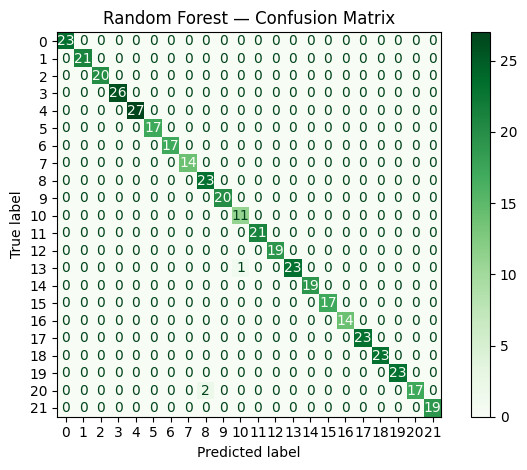

In [38]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Greens")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. Metrics Bar Chart

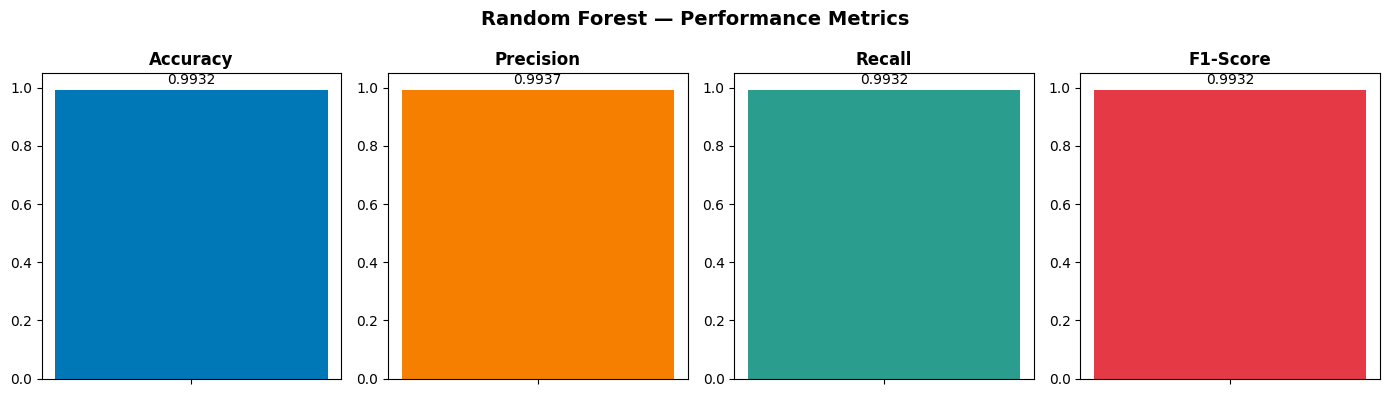

In [39]:
colors = ["#0077B6", "#F77F00", "#2A9D8F", "#E63946"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (_, row), color in zip(axes, results_df.iterrows(), colors):
    ax.bar([row["Metric"]], [row["Score"]], color=color, width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(row["Metric"], fontsize=12, fontweight="bold")
    ax.text(0, row["Score"] + 0.02, f"{row['Score']:.4f}", ha="center", fontsize=10)
    ax.tick_params(axis="x", labelbottom=False)

fig.suptitle("Random Forest — Performance Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Test with Unseen Data

In [40]:
unseen_data = np.array([
    [90, 40, 40, 21.0, 80.0, 6.5, 200.0],
    [60, 55, 44, 25.0, 70.0, 7.0, 120.0],
    [20, 30, 20, 28.0, 60.0, 5.5, 80.0],
    [40, 60, 50, 22.0, 85.0, 6.8, 250.0],
])

rf_unseen_pred = rf_model.predict(unseen_data)
rf_crops = le.inverse_transform(rf_unseen_pred)

unseen_results = pd.DataFrame({
    "Sample": [f"Sample {i+1}" for i in range(len(unseen_data))],
    "Random Forest Prediction": rf_crops,
})
unseen_results

j:\fyp\AI Microservices\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Sample,Random Forest Prediction
0,Sample 1,rice
1,Sample 2,jute
2,Sample 3,mothbeans
3,Sample 4,papaya


## 11. Export Model & Label Encoder to `export/`

In [41]:
export_dir = PROJECT_ROOT / "export"
os.makedirs(export_dir, exist_ok=True)
print(f"Export directory: {export_dir}")

model_path = export_dir / "crop_recommendation_random_forest_model.pkl"
encoder_path = export_dir / "crop_recommendation_label_encoder.pkl"

joblib.dump(rf_model, model_path)
joblib.dump(le, encoder_path)

print(f"Model saved to:   {model_path}")
print(f"Encoder saved to: {encoder_path}")
print(f"Model file exists: {model_path.exists()}")
print(f"Encoder file exists: {encoder_path.exists()}")

Export directory: J:\fyp\AI Microservices\export
Model saved to:   J:\fyp\AI Microservices\export\crop_recommendation_random_forest_model.pkl
Encoder saved to: J:\fyp\AI Microservices\export\crop_recommendation_label_encoder.pkl
Model file exists: True
Encoder file exists: True
